# Multiple Linear Regression

## Goal

Extend simple linear regression from one input feature to several. By the end, you will be able to:

- distinguish simple and multiple linear regression;
- write scalar and vector prediction equations;
- interpret the intercept and each coefficient correctly;
- understand line, plane, and hyperplane geometry;
- represent house-price features in a design matrix;
- fit a multiple linear regression model with least squares;
- make a new prediction and measure training error;
- recognize scaling, categorical-variable, multicollinearity, and extrapolation issues.

**Source material:** the supplied multiple-linear-regression transcript and slides. Repetition has been removed and technical language has been clarified.


## 1. From simple to multiple linear regression

Simple linear regression uses one independent feature:

$$\hat y=\theta_0+\theta_1x$$

Multiple linear regression uses two or more independent features:

$$
\boxed{\hat y=\theta_0+\theta_1x_1+\theta_2x_2+\cdots+\theta_px_p}
$$

| Point | Simple linear regression | Multiple linear regression |
|---|---|---|
| Input features | One | Two or more |
| Coefficients | One slope coefficient | One coefficient per feature |
| Intercept | Usually one | Usually one |
| Geometry | Line in 2D | Plane in 3D or hyperplane in higher dimensions |
| Example | Weight → height | Size, rooms, location → price |

The observed feature values are fixed training inputs. Training changes the parameters $\theta_0,\theta_1,\ldots,\theta_p$ to reduce prediction error.


## 2. House-price example

Suppose the target is house price and the inputs are:

- $x_1$: number of rooms;
- $x_2$: size in square feet;
- $x_3$: location information.

The prediction equation is:

$$
\hat y=\theta_0+\theta_1(\text{rooms})+\theta_2(\text{size})+\theta_3(\text{location feature})
$$

Location is categorical, so it should not usually be assigned arbitrary codes such as Chandigarh = 1, Mohali = 2, Kharar = 3. Those numbers falsely imply a numeric distance and order. A common solution is **one-hot encoding**, which creates indicator columns such as `premium_location = 0 or 1`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic teaching data. Prices are in lakh INR.
rooms = np.array([1, 2, 2, 3, 3, 3, 4, 4, 5, 5], dtype=float)
size_sqft = np.array([550, 760, 900, 1050, 1200, 1350, 1500, 1700, 1950, 2200], dtype=float)
premium_location = np.array([0, 0, 1, 0, 1, 0, 1, 0, 1, 1], dtype=float)
price_lakh = np.array([26, 34, 44, 47, 59, 58, 73, 72, 91, 102], dtype=float)

print("rows | rooms | size_sqft | premium_location | price_lakh")
for row in zip(range(1, len(rooms) + 1), rooms, size_sqft, premium_location, price_lakh):
    print(f"{row[0]:>4} | {row[1]:>5.0f} | {row[2]:>9.0f} | {row[3]:>16.0f} | {row[4]:>10.1f}")


rows | rooms | size_sqft | premium_location | price_lakh
   1 |     1 |       550 |                0 |       26.0
   2 |     2 |       760 |                0 |       34.0
   3 |     2 |       900 |                1 |       44.0
   4 |     3 |      1050 |                0 |       47.0
   5 |     3 |      1200 |                1 |       59.0
   6 |     3 |      1350 |                0 |       58.0
   7 |     4 |      1500 |                1 |       73.0
   8 |     4 |      1700 |                0 |       72.0
   9 |     5 |      1950 |                1 |       91.0
  10 |     5 |      2200 |                1 |      102.0


## 3. Meaning of the parameters

For

$$\hat y=\theta_0+\theta_1x_1+\theta_2x_2+\theta_3x_3,$$

- $\theta_0$ is the predicted target when all features equal zero;
- $\theta_j$ is the predicted change in $y$ for a one-unit increase in $x_j$, **holding all other included features constant**.

That last phrase is essential. In multiple regression, a coefficient is a partial relationship, not just the raw relationship between one feature and the target.

Coefficient units also matter. If price is in lakh INR and size is in square feet, the size coefficient is measured in lakh INR per square foot.

The intercept may be mathematically necessary even when the all-zero house is not realistic. Some models intentionally omit an intercept, but including one is the standard default.


## 4. Vector and matrix notation

For one house:

$$
\mathbf{x}=\begin{bmatrix}x_1\\x_2\\\vdots\\x_p\end{bmatrix},\qquad
\boldsymbol\theta=\begin{bmatrix}\theta_1\\\theta_2\\\vdots\\\theta_p\end{bmatrix}
$$

$$\hat y=\theta_0+\mathbf{x}^T\boldsymbol\theta$$

For all $n$ houses, put a column of ones and all features into the **design matrix** $X$:

$$
X=\begin{bmatrix}
1 & x_1^{(1)} & \cdots & x_p^{(1)}\\
1 & x_1^{(2)} & \cdots & x_p^{(2)}\\
\vdots & \vdots & \ddots & \vdots\\
1 & x_1^{(n)} & \cdots & x_p^{(n)}
\end{bmatrix}
$$

The parameter vector now includes the intercept:

$$\boldsymbol\beta=[\theta_0,\theta_1,\ldots,\theta_p]^T$$

All predictions are computed at once:

$$\hat{\mathbf y}=X\boldsymbol\beta$$


In [2]:
X_features = np.column_stack([rooms, size_sqft, premium_location])
X_design = np.column_stack([np.ones(len(rooms)), X_features])

print("Feature matrix shape:", X_features.shape)
print("Design matrix shape:", X_design.shape)
print("First design row:", X_design[0].tolist())


Feature matrix shape: (10, 3)
Design matrix shape: (10, 4)
First design row: [1.0, 1.0, 550.0, 0.0]


## 5. Fit the coefficients with least squares

Multiple linear regression usually minimizes squared residuals:

$$
J(\boldsymbol\beta)=\frac{1}{2n}\|X\boldsymbol\beta-\mathbf y\|_2^2
$$

The optimum can be found with a numerically stable least-squares solver. Gradient descent is another option:

$$
\boldsymbol\beta\leftarrow\boldsymbol\beta-\alpha\frac{1}{n}X^T(X\boldsymbol\beta-\mathbf y)
$$

With more features, every coefficient participates in optimization. The cost surface cannot usually be drawn directly, but the mathematics is the same.


In [3]:
# np.linalg.lstsq uses a stable least-squares computation.
coefficients, residual_sum, rank, singular_values = np.linalg.lstsq(
    X_design, price_lakh, rcond=None
)
intercept, rooms_coef, size_coef, premium_coef = coefficients

print(f"Intercept:                  {intercept:8.3f} lakh")
print(f"Rooms coefficient:          {rooms_coef:8.3f} lakh per extra room")
print(f"Size coefficient:           {size_coef:8.4f} lakh per extra sq ft")
print(f"Premium-location coefficient:{premium_coef:7.3f} lakh")
print("Matrix rank:", rank)


Intercept:                     1.513 lakh
Rooms coefficient:             1.589 lakh per extra room
Size coefficient:             0.0386 lakh per extra sq ft
Premium-location coefficient:  6.433 lakh
Matrix rank: 4


Interpretation of the fitted teaching model:

- holding size and location constant, one extra room changes predicted price by the rooms coefficient;
- holding rooms and location constant, one extra square foot changes predicted price by the size coefficient;
- holding rooms and size constant, a premium location changes predicted price by the indicator coefficient.

These are associations estimated from the supplied rows. They do not prove causal effects.


## 6. Make a new prediction

For a new house with 3 rooms, 1,280 square feet, and a premium-location indicator of 1:

$$
\hat y=\theta_0+3\theta_1+1280\theta_2+1\theta_3
$$

Prediction uses the same feature order and encoding used during training.


In [4]:
new_house = np.array([1.0, 3.0, 1280.0, 1.0])  # 1 is the intercept column
new_price = new_house @ coefficients
print(f"Predicted price: {new_price:.2f} lakh INR")


Predicted price: 62.11 lakh INR


## 7. Inspect predictions and residuals

A residual is:

$$e_i=y_i-\hat y_i$$

The best-fit model minimizes the sum of squared residuals on the training data. Residual plots help reveal patterns the model failed to learn. A strong curve or funnel shape suggests that a plain linear model may be inappropriate.


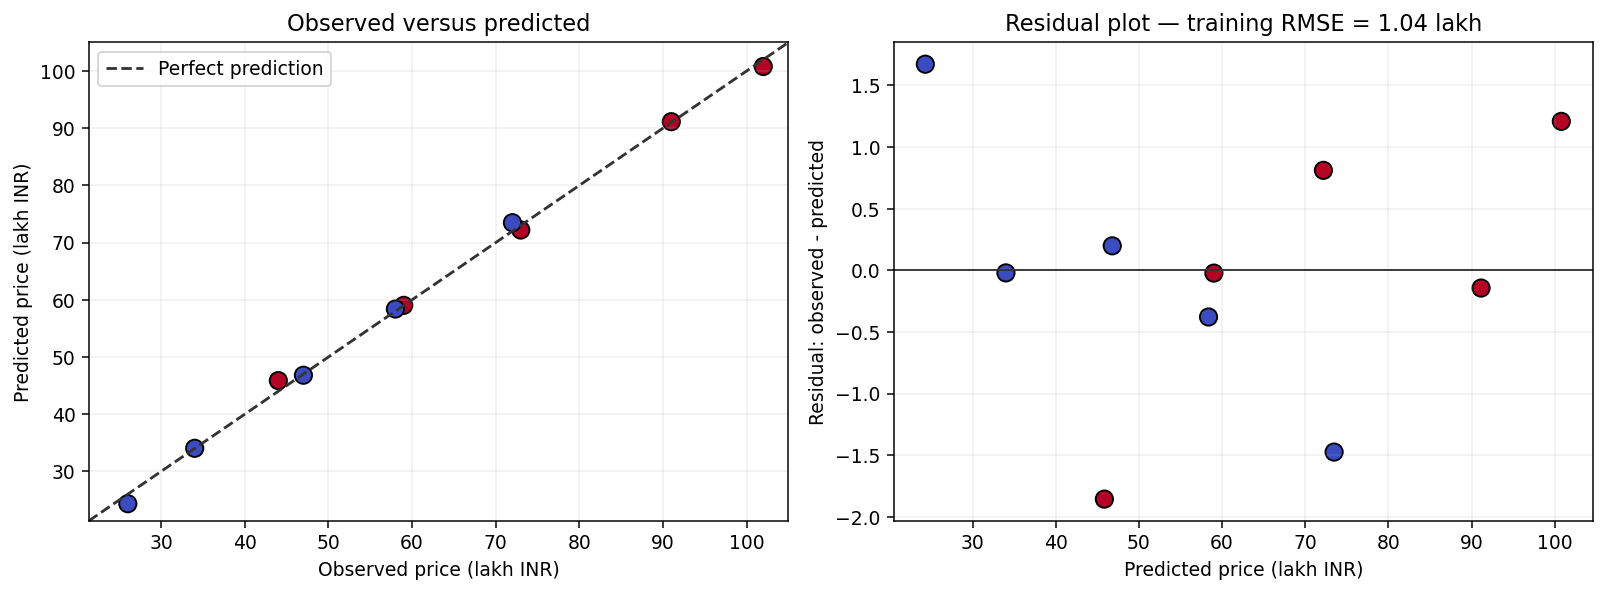

In [5]:
fitted_prices = X_design @ coefficients
residuals = price_lakh - fitted_prices
rmse = np.sqrt(np.mean(residuals ** 2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(price_lakh, fitted_prices, c=premium_location, cmap="coolwarm",
                s=85, edgecolor="black")
limits = [min(price_lakh.min(), fitted_prices.min()) - 3,
          max(price_lakh.max(), fitted_prices.max()) + 3]
axes[0].plot(limits, limits, "--", color="#333333", label="Perfect prediction")
axes[0].set_xlim(limits)
axes[0].set_ylim(limits)
axes[0].set_xlabel("Observed price (lakh INR)")
axes[0].set_ylabel("Predicted price (lakh INR)")
axes[0].set_title("Observed versus predicted")
axes[0].grid(alpha=0.2)
axes[0].legend()

axes[1].axhline(0, color="#333333", linewidth=1)
axes[1].scatter(fitted_prices, residuals, c=premium_location, cmap="coolwarm",
                s=85, edgecolor="black")
axes[1].set_xlabel("Predicted price (lakh INR)")
axes[1].set_ylabel("Residual: observed - predicted")
axes[1].set_title(f"Residual plot — training RMSE = {rmse:.2f} lakh")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


## 8. Geometry: line, plane, and hyperplane

- One feature plus the target can be shown as a line in 2D.
- Two features plus the target form a plane in 3D.
- Three or more features require a higher-dimensional hyperplane that cannot be viewed directly.

The model is still *linear in its parameters*. “Linear” does not mean each input must act alone: engineered terms such as $x_1x_2$ or $x_1^2$ can be included as new columns while the coefficients remain linear.


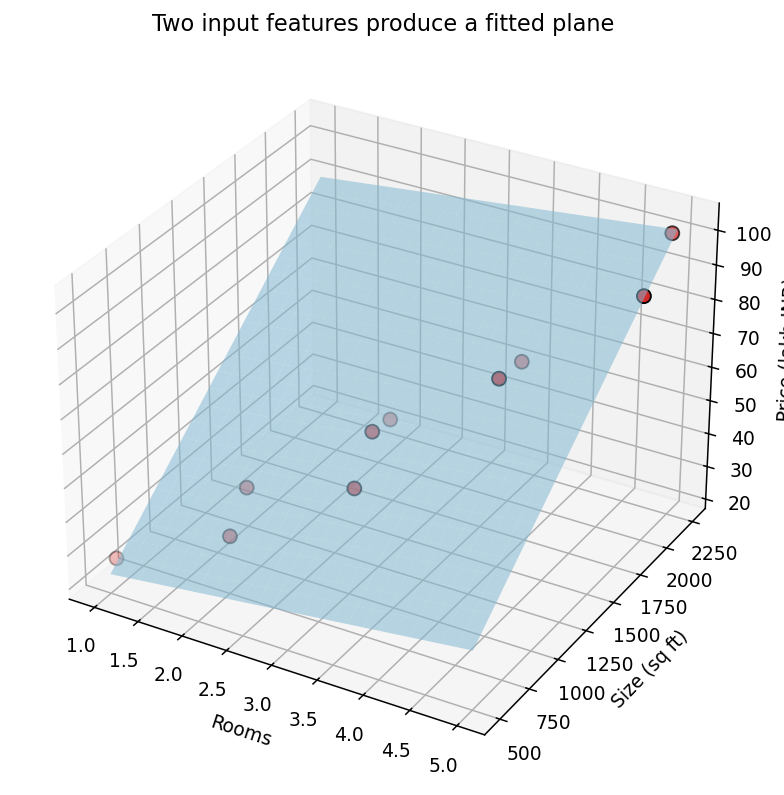

In [6]:
from mpl_toolkits.mplot3d import Axes3D  # registers the 3D projection

# For a clean 3D illustration, refit using only rooms and size.
X_two = np.column_stack([np.ones(len(rooms)), rooms, size_sqft])
beta_two, *_ = np.linalg.lstsq(X_two, price_lakh, rcond=None)

room_grid, size_grid = np.meshgrid(
    np.linspace(1, 5, 25), np.linspace(500, 2250, 25)
)
price_grid = beta_two[0] + beta_two[1] * room_grid + beta_two[2] * size_grid

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(rooms, size_sqft, price_lakh, s=55, color="#D62828", edgecolor="black")
ax.plot_surface(room_grid, size_grid, price_grid, alpha=0.55, color="#8ECAE6", edgecolor="none")
ax.set_xlabel("Rooms")
ax.set_ylabel("Size (sq ft)")
ax.set_zlabel("Price (lakh INR)")
ax.set_title("Two input features produce a fitted plane")
plt.tight_layout()
plt.show()


## 9. Important practical issues

### Feature scaling

Rooms and square feet have very different numeric scales. Least-squares solvers can handle this example, but scaling often improves numerical conditioning and gradient-descent speed. Interpret coefficients in the original units or transform them back.

### Multicollinearity

If two features carry almost the same information—such as size in square feet and size in square metres—individual coefficients can become unstable even when predictions remain reasonable.

### Categorical variables

Use suitable encodings. With an intercept, omit one one-hot category as the reference to avoid perfect redundancy (“dummy-variable trap”).

### Irrelevant features

Adding features can increase training $R^2$ without improving future predictions. Use validation/test performance, domain logic, adjusted $R^2$, or regularization.

### Non-linearity and interactions

Price may respond non-linearly to size, and the effect of size may differ by location. Residual plots and domain understanding can motivate transformed or interaction features.

### Extrapolation

Predicting a 10,000-square-foot house from data ending near 2,200 square feet is risky, even if the equation returns a number.


## 10. Common mistakes

1. Calling the fitted object a “line” when there are several inputs; it is a plane or hyperplane.
2. Interpreting a coefficient without saying “holding other included features constant.”
3. Giving categories arbitrary ordered numbers.
4. Changing feature order between training and prediction.
5. Adding every available column without checking usefulness or leakage.
6. Reading a strong association as proof of causation.
7. Comparing raw coefficient sizes when features use different units.
8. Judging the model only on the same data used to fit it.


## 11. Quick revision sheet

- **Simple regression:** one input feature.
- **Multiple regression:** two or more input features.
- **Equation:** $\hat y=\theta_0+\sum_{j=1}^{p}\theta_jx_j$.
- **Intercept:** $\theta_0$.
- **Feature coefficient:** expected change in prediction for a one-unit feature increase, holding other included features fixed.
- **Design matrix:** rows are examples; columns are the intercept and features.
- **Predictions:** $\hat{\mathbf y}=X\boldsymbol\beta$.
- **Least squares:** minimizes squared residuals.
- **Two inputs:** fitted plane.
- **Many inputs:** fitted hyperplane.
- **One-hot encoding:** represents unordered categories with indicator columns.
- **Multicollinearity:** strong redundancy between predictors.


## 12. Quick questions — answer before checking below

1. What makes regression “multiple” rather than “simple”?
2. Write the prediction equation for $p$ features.
3. How many feature coefficients are used for $p$ input features?
4. How many intercepts are normally used?
5. In house pricing, identify three possible inputs and the target.
6. What does $\theta_2$ mean in a multiple-regression equation?
7. Why must coefficient interpretation include “holding other features constant”?
8. What is the purpose of the design matrix's column of ones?
9. Write the matrix prediction equation.
10. What object is fitted with two input features and one target?
11. Why is arbitrary integer coding risky for locations?
12. What is multicollinearity?
13. Why can adding an irrelevant feature be harmful?
14. What should be preserved when predicting a new row?
15. Does regression prove that a feature causes the target to change?


## 13. Answer key

1. It uses two or more independent input features.
2. $\hat y=\theta_0+\sum_{j=1}^{p}\theta_jx_j$.
3. $p$: one coefficient per input feature.
4. Normally one intercept, unless the model is deliberately fitted without one.
5. Inputs can be rooms, size, and encoded location; the target is price.
6. The predicted change in the target for a one-unit increase in $x_2$, holding other included inputs constant.
7. Each coefficient represents a partial relationship after accounting for the other model features.
8. Its coefficient becomes the intercept $\theta_0$.
9. $\hat{\mathbf y}=X\boldsymbol\beta$.
10. A plane in three-dimensional space.
11. The numbers create a false order and distance between unordered categories.
12. Strong redundancy or linear dependence among predictors, which can destabilize coefficient estimates.
13. It can add noise, complexity, unstable estimates, and overfitting without improving unseen predictions.
14. The exact feature definitions, units, order, and preprocessing/encoding used during training.
15. No. Regression estimates associations unless a suitable causal design supports a causal claim.
